#Neural Machine Translation (RNN-Attention)
### Translating English text to Igbo using attention enabled Encoder-Decoder model.

###1. **What is Attention mechanism?**
#### Before understanding the attention mechanism, first let's take a quick look at Encoder-Decoder architecture.

###  Encoder-Decoder model:
![encoder decoder image](https://queirozf.com/images/contents/ZZqXAUp.png)

#### The Encoder-Decoder architecture with recurrent neural networks has become an effective and standard approach for both neural machine translation (NMT) and sequence-to-sequence (seq2seq) prediction in general. The key benefits of the approach are the ability to train a single end-to-end model directly on source and target sentences and the ability to handle variable length input and output sequences of text.
#### An Encoder-Decoder architecture was developed where an input sequence was read in entirety and encoded to a *fixed-length internal representation*. A decoder network then used this internal representation to output words until the end of sequence token was reached. LSTM networks were used for both the encoder and decoder.
#### It works fairly well but without attention the performance drops as the length of the sentences increase.
![bleu score encoder-decoder](https://3qeqpr26caki16dnhd19sv6by6v-wpengine.netdna-ssl.com/wp-content/uploads/2017/10/Loss-in-model-skill-with-increased-sentence-length.png)

###  Attention model:
**Attention is a mechanism that was developed to improve the performance of the Encoder-Decoder RNN on machine translation. It was proposed as a solution to the limitation of the Encoder-Decoder model encoding the input sequence to one *fixed length internal representation* from which to decode each output time step. This issue was believed to be more of a problem when decoding long sequences. Instead of encoding the input sequence into a single fixed context vector, the attention model develops a context vector that is filtered specifically for each output time step.** 

#### As with the Encoder-Decoder paper, the technique is applied to a machine translation problem and uses GRU units rather than LSTM memory cells. But in this project I'll be using LSTM memory cells.
reference 1: https://machinelearningmastery.com/encoder-decoder-recurrent-neural-network-models-neural-machine-translation/

reference 2: https://machinelearningmastery.com/how-does-attention-work-in-encoder-decoder-recurrent-neural-networks/

###  How do Attention models work?
***
Since the attention models are encoder-decoder models with attention mechanism, they function very similar to encoder-decoder models but with a catch. Given a problem of generating an output text sequence from input text sequence (Ex. converting a English sentence to Igbo), let's quickly go through the working of a encoder decoder model step by step:
***
1. Encoding: The input sentence is first encoded as a single fixed-length vector.
2. Score calculation: The encoded input sentence flows through the encoder and decoder. The decoder outputs one value at a time, which is passed on to perhaps more layers before finally outputting a prediction (y) for the current output time step. The alignment model scores (e) how well each encoded input (h) matches the current output of the decoder (s). The calculation of the score requires the output from the decoder from the previous output time step, e.g. s(t-1). When scoring the very first output for the decoder, this will be 0. Scoring is performed using a **function a()**.
3. Annotation weights calculation: Next, the alignment scores are normalized using a softmax function. The normalization of the scores allows them to be treated like probabilities, indicating the likelihood of each encoded input time step (annotation) being relevant to the current output time step. These normalized scores are called annotation weights.
4. Context-vector calculation: Next, each annotation (h) is multiplied by the annotation weights (a) to produce a new attended context vector from which the current output time step can be decoded.
5. Decoding: Decoding is then performed as per the Encoder-Decoder model, although in this case using the attended context vector for the current time step.

Find the original paper here: https://arxiv.org/abs/1706.03762

#### Remember in the step 2 'Score calculation' the scoring is performed using a function. Now there are many scoring functions out there but in this project I'll be using *general method* for score calculation.
<img src="https://i.ibb.co/dWB96PX/Screen-Shot-2020-08-19-at-4-44-12-AM.png" alt="Screen-Shot-2020-08-19-at-4-44-12-AM" border="0">

#1. Importing Libraries

In [ ]:
#pip install janome

In [ ]:
# Importing the necessary libraries.
from tensorflow.compat.v1.keras.layers import CuDNNLSTM, CuDNNGRU
from tensorflow.keras.preprocessing.sequence import pad_sequences
from nltk.translate.bleu_score import sentence_bleu as bleu
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Layer
from tensorflow.keras.layers import Dense, Embedding
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import TimeDistributed
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import tensorflow as tf
import seaborn as sns
import pandas as pd
import numpy as np
import datetime
import warnings
import time
import re
import os
# warnings.filterwarnings("ignore", message="Glyph \d+ missing from current font.")
warnings.simplefilter("ignore")
sns.set()
tf.compat.v1.enable_eager_execution()
tf.keras.backend.clear_session()

## Checking for GPU

In [ ]:
import torch

# if there's a GPU available...
if torch.cuda.is_available():

  # Tell Pytorch to use the GPU.
  device = torch.device('cuda')

  print('There are %d GPU(s) available.' % torch.cuda.device_count())
  print('We will use the GPU:', torch.cuda.get_device_name(0))
else:
  print('No GPU available, using th CPU instead')
  device = torch.device('CPU')

There are 1 GPU(s) available.
We will use the GPU: Tesla K80


#2. Data Collection

In [ ]:
"""
#Using English to French
f = open('/content/fra.txt').read() # reading data from file
data_ = [line.split('\t')[:2] for line in f.split('\n')[:-1]] # removing attribution
#data_ = data_[0:50000]
df = pd.DataFrame(data_, columns=['English', 'French'])
print('Dimensions of the data as a dataframe:')
df.shape """

"\n#Using English to French\nf = open('/content/fra.txt').read() # reading data from file\ndata_ = [line.split('\t')[:2] for line in f.split('\n')[:-1]] # removing attribution\n#data_ = data_[0:50000]\ndf = pd.DataFrame(data_, columns=['English', 'French'])\nprint('Dimensions of the data as a dataframe:')\ndf.shape "

In [ ]:
#igbo datast
def load_data(path):
    """
    Load dataset
    """
    input_file = os.path.join(path)
    with open(input_file, "r") as f:
        data = f.read()

    return data.strip().split('\n')

f_e = open('train_en.txt').read() # reading data from file
f_i = open('train.ig.txt').read() # reading data from file

#training datasets
#eng train
train_en = load_data('train_en.txt')
#igbo train
train_ig = load_data('train.ig.txt')


# checking the lenght
print('length of train_igbo',len(train_ig))
print('length of train_english', len(train_en))

# put our data into dataframe
df = pd.DataFrame(train_en, columns=['English'])
df['Igbo'] = train_ig

length of train_igbo 10000
length of train_english 10000


#3. Data preprocessing

In [ ]:
mispell_dict = {"aren't" : "are not", "can't" : "cannot", "couldn't" : "could not", 
                "couldnt" : "could not", "didn't" : "did not", "doesn't" : "does not", 
                "doesnt" : "does not", "don't" : "do not", "hadn't" : "had not", 
                "hasn't" : "has not", "haven't" : "have not", "havent" : "have not", 
                "he'd" : "he would", "he'll" : "he will", "he's" : "he is", "i'd" : "I would",
                "i'd" : "I had", "i'll" : "I will", "i'm" : "I am", "isn't" : "is not", 
                "it's" : "it is", "it'll":"it will", "i've" : "I have", "let's" : "let us", 
                "mightn't" : "might not", "mustn't" : "must not", "shan't" : "shall not", 
                "she'd" : "she would", "she'll" : "she will", "she's" : "she is", 
                "shouldn't" : "should not", "shouldnt" : "should not", "that's" : "that is", 
                "thats" : "that is", "there's" : "there is", "theres" : "there is", 
                "they'd" : "they would", "they'll" : "they will", "they're" : "they are", 
                "theyre": "they are", "they've" : "they have", "we'd" : "we would", 
                "we're" : "we are", "weren't" : "were not", "we've" : "we have", 
                "what'll" : "what will", "what're" : "what are", "what's" : "what is", 
                "what've" : "what have", "where's" : "where is", "who'd" : "who would",
                "who'll" : "who will", "who're" : "who are", "who's" : "who is", 
                "who've" : "who have", "won't" : "will not", "wouldn't" : "would not", 
                "you'd" : "you would", "you'll" : "you will", "you're" : "you are", 
                "you've" : "you have", "'re": " are", "wasn't": "was not", "we'll":" will", 
                "didn't": "did not", "tryin'":"trying"
                }

def deconcate(sent):
    keys = mispell_dict.keys()
    cleaned_sentence = []
    for word in sent.split(' '):
        if word in keys:
            cleaned_sentence.append(mispell_dict[word])
        else:
            cleaned_sentence.append(word)
    return ' '.join(cleaned_sentence)

In [ ]:
# calling tokenizer function
token_object = Tokenizer()

def preprocess(phrase):
  phrase = phrase.strip().lower()
  #phrase = deconcate(phrase)
  phrase = '<sos> '+ phrase.lower() +' <eos>'
  return phrase



In [ ]:
df.head()

,English,Igbo
0,The news that will interest you:,Akụkọ ndị ga-amasị gị:
1,"Joseph Achuzie, the Biafran brave man is gone.","Joseph Achuzie, Dike Biafra alala"
2,Dapchi: Government has not defeated Boko Haram...,Dapchi: Gọọmenti emeribeghị Boko Haram - Massob
3,Tottenham look forward to lifting the FA cup i...,Tottenham na-ele anya iburu iko FA na mmeri Ro...
4,"Son Heung-min, Fernando Llorente and Kyle Walt...","Son Heung-min, Fernando Llorente na Kyle Walte..."


In [ ]:
df.tail()

,English,Igbo
9995,‘‘At the nascent stage of USSD development for...,N'oge mbilite nke mwuli USSD maka ngalaba ozi ...
9996,Green House won the track events while White H...,Ụlọ akwụkwọ ndụ meriri n'egwuregwu ọwara ebe Ụ...
9997,"However, “following complaints by its customer...","Etu ọ dị, site na mkpesa sitere n'aka ndị ahịa..."
9998,Calisthenics and match past added glamour to t...,egwu kalịstenis na ife aka mere ka emume ahụ d...
9999,These are according to a letter obtained from ...,"Dịka ọ si dị na leta sitere n'ụlọ ọrụ, nke nwe..."


In [ ]:
#english_sentences = df['English'].tolist()
#igbo_sentences = df['French'].tolist()
"""
# preprocessing the sentences by stripping and adding <sos>, <eos>
english, japanese = [], []
for line in tqdm(f.split('\n')[:-1]):
  japanese.append(preprocess(line.split('\t')[0]))
  jp_ = ' '.join([x.surface for x in token_object(line.split('\t')[1])])
  english.append(preprocess(jp_)) 
#English FRench
# preprocessing the sentences by stripping and adding <sos>, <eos>
igbo, english = [], []
for line in tqdm(f.split('\n')[:-1]):
  igbo.append(preprocess(line.split('\t')[0]))
for line in tqdm(f.split('\n')[:-1]):
  #jp_ = ' '.join([x.surface for x in token_object.tokenize(line.split('\t')[0])])
  english.append(preprocess(line.split('\t')[1])) """


"\n# preprocessing the sentences by stripping and adding <sos>, <eos>\nenglish, japanese = [], []\nfor line in tqdm(f.split('\n')[:-1]):\n  japanese.append(preprocess(line.split('\t')[0]))\n  jp_ = ' '.join([x.surface for x in token_object(line.split('\t')[1])])\n  english.append(preprocess(jp_)) \n#English FRench\n# preprocessing the sentences by stripping and adding <sos>, <eos>\nigbo, english = [], []\nfor line in tqdm(f.split('\n')[:-1]):\n  igbo.append(preprocess(line.split('\t')[0]))\nfor line in tqdm(f.split('\n')[:-1]):\n  #jp_ = ' '.join([x.surface for x in token_object.tokenize(line.split('\t')[0])])\n  english.append(preprocess(line.split('\t')[1])) "

In [ ]:
# preprocessing the sentences by stripping and adding <sos>, <eos>
igbo, english = [], []
for line in tqdm(f_e.split('\n')[:-1]):
  igbo.append(preprocess(line.split('\t')[0]))
for line in tqdm(f_i.split('\n')[:-1]):
  #jp_ = ' '.join([x.surface for x in token_object.tokenize(line.split('\t')[0])])
  english.append(preprocess(line.split('\t')[0]))

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

In [ ]:
print(english[150])
print(igbo[150])


<sos> ezenwaanyị elizabeth <eos>
<sos> queen elizabeth <eos>


In [ ]:
#igbo = igbo[0:50000]
#english = english[0:50000]

In [ ]:
len(english)

10000

## Text Processing and Analysis

In [ ]:
_eng_len = [len(x.split(' '))-2 for x in train_en]
_jpn_len = [len(x.split(' '))-2 for x in train_ig]

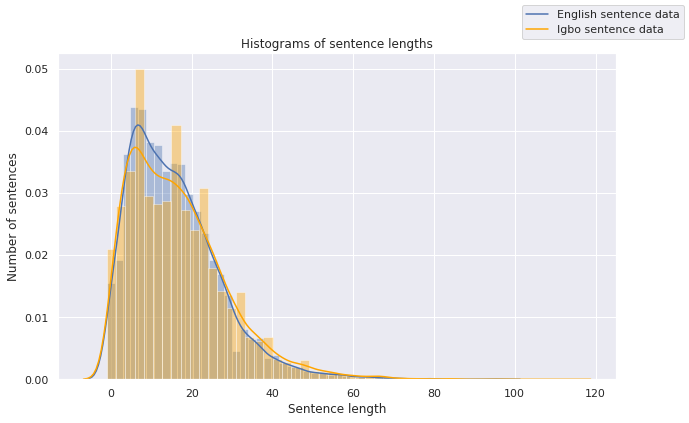

In [ ]:
sns.set()
fig = plt.figure(figsize=(10,6))
sns.distplot(_eng_len)
sns.distplot(_jpn_len, color='orange')
fig.legend(labels=['English sentence data','Igbo sentence data'])
plt.xlabel('Sentence length')
plt.ylabel('Number of sentences')
plt.title('Histograms of sentence lengths')
plt.show()

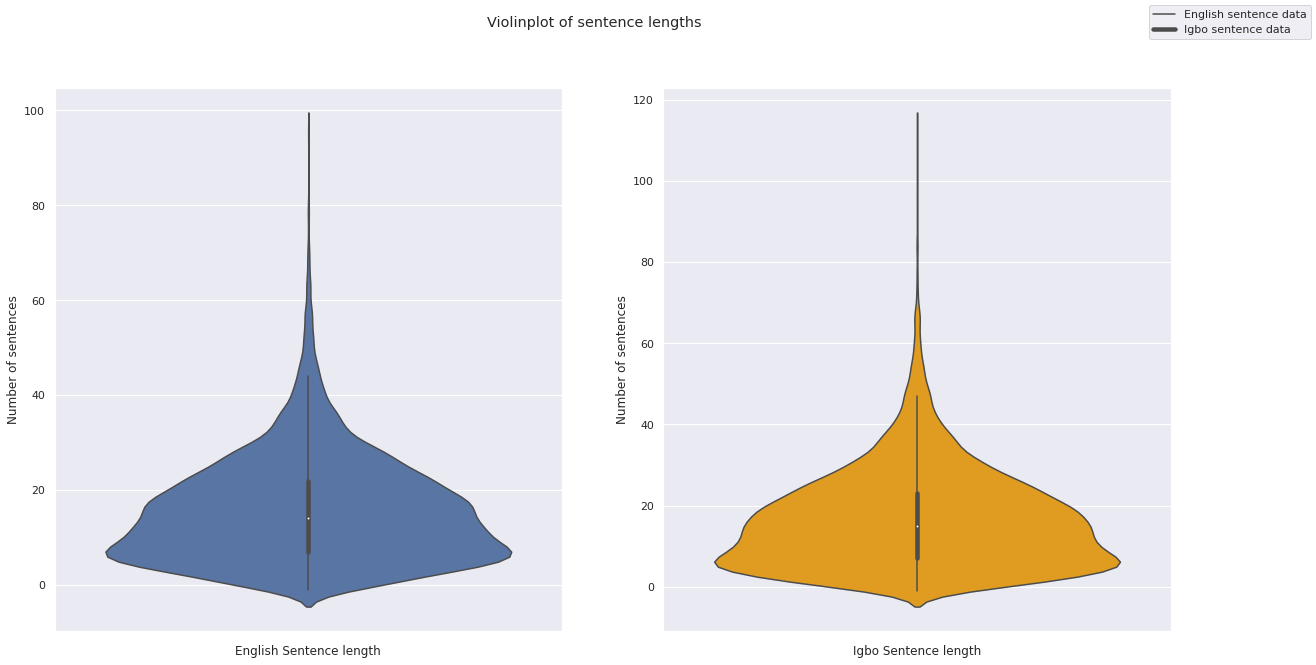

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(20, 10))
sns.violinplot(y = _eng_len, ax=ax[0], orient='v')
fig.suptitle('Violinplot of sentence lengths')
ax[0].set_xlabel('English Sentence length')
ax[0].set_ylabel('Number of sentences')
sns.violinplot(y = _jpn_len, ax=ax[1], orient='v', color='orange')
ax[1].set_xlabel('Igbo Sentence length')
ax[1].set_ylabel('Number of sentences')
fig.legend(labels=['English sentence data','Igbo sentence data'])
plt.show();

 Seems...Our dataset is symmetric and the sentence length matches The Igbo sentences tend to have a close word length than the English sentences.

## Tokenizer and  Vocabulary Building

In [ ]:
# initializing tokenizer To convert the words into numerical representation
filters = "+1234567890\"#$%&()*+,-/:;=@[\\]^_`{|}~'"
tokenizer_eng = Tokenizer(split=' ', 
                          char_level=False, 
                          filters=filters)
# fitting on english
tokenizer_eng.fit_on_texts(english)
eng_tokens = tokenizer_eng.texts_to_sequences(english)

# fitting on Igbo
tokenizer_jpn = Tokenizer(lower=True, split=' ', char_level=False, filters=filters)
tokenizer_jpn.fit_on_texts(igbo)
jpn_tokens = tokenizer_jpn.texts_to_sequences(igbo)

In [ ]:
# defining the vocabulary size of english and Igbo language in the given data.
eng_vocab = len(tokenizer_eng.word_index.items()) + 1
jpn_vocab = len(tokenizer_jpn.word_index.items()) + 1

In [ ]:
total = ([x for x in igbo for x in x.split()])
print('total english words',len(total))
print(' english vocabulary',jpn_vocab)
print()
total2 = ([x for x in df.Igbo.tolist() for x in x.split()])
print('total Igbo words',len(total2))
print(' Igbo vocabulary',eng_vocab)

total english words 196375
 english vocabulary 16224

total Igbo words 184538
 Igbo vocabulary 14789


In [ ]:
# defining the max length of english and Igbo sentence in the given data (for padding).
# we assign values due to outlies
eng_max = 60 #  max([len(e) for e in eng_tokens]) #50
jpn_max = 60 # max([len(i) for i in jpn_tokens]) #40

In [ ]:
# Padding the tokenized data
eng_padded = pad_sequences(eng_tokens, maxlen=eng_max, padding='post')
jpn_padded = pad_sequences(jpn_tokens, maxlen=jpn_max, padding='post')

In [ ]:
# splitting data into train and test
eng_tr, eng_te, jpn_tr, jpn_te = train_test_split(eng_padded, jpn_padded, test_size=0.03, random_state=42)

In [ ]:
eng_tr.shape, jpn_tr.shape, eng_te.shape, jpn_te.shape

((9700, 60), (9700, 60), (300, 60), (300, 60))

## Parameter for Training

Few parameters that will be useful for the training procedure and the overall preparation of the dataset.

In [ ]:
BUFFER_SIZE = len(eng_tr)
BATCH_SIZE = 128 * 2
N_BATCH = BUFFER_SIZE//BATCH_SIZE
embedding_dim = 256
Lstm_units = 1024
dec_units = 1024
#EPOCHS = 5
print(N_BATCH)

dataset = tf.data.Dataset.from_tensor_slices((jpn_tr, eng_tr)).shuffle(BUFFER_SIZE)
dataset = dataset.batch(BATCH_SIZE, drop_remainder=True)

37


In [ ]:
dataset.element_spec

(TensorSpec(shape=(256, 60), dtype=tf.int32, name=None),
 TensorSpec(shape=(256, 60), dtype=tf.int32, name=None))

#4. Building Seq2Seq Model

##4.1 Encoder layer
The encoder will contain the required LSTMs structures and embeddings.
The encoder network is an RNN whose job is to read a sequence of vectors $\textbf{x}=(x_1,...,x_T)$ into a vector $c$, such that:

$$\begin{aligned}h_t = f(x_t, h_{t-1}) \\
c = q({h_1,...,h_T}),
\end{aligned}$$

where $h_t \in \mathbb{R}^n$ is the hidden state at time $t$, $c$ is a vector generated from the sequence of the hidden states and $f$ and $q$ are nonlinear functions.

Our approach for the encoder architecture is to use the main class Encoder. Then, we will utilize a couple of functions, namely the __init__ function, the initialize states block, and the call blocks. In the init block, we will define and initialize all the required parameters.

In the call block of the encoder, we define a function such that it takes an input sequence and the initial states of the encoder. The input of the input sequences is passed through the embedding layer, and finally, the output of the embedding layer is passed into the Encoder LSTM. The call function returns all the outputs of the encoder as well as the last time steps of the hidden and cell states.

Before defining our encoder network, we introduced a layer that learns the 128-dimensional representation (the size of the embedding space) of the end token for the English corpus. Therefore, the input dimension to the RNN was increased by 1. The RNN consists of a Long Short-Term Memory (LSTM) layer with 1024 units.  The encoder is a multi-output model: it outputs the hidden state and cell states of the LSTM layer. The output of the LSTM layer is not used in a sequence to sequence architecture.

In [ ]:
class Encoder(tf.keras.layers.Layer):
    def __init__(self, vocab_size, embedding_dim, enc_units):
        super().__init__()
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.enc_units = enc_units
        
    def build(self, input_shape):
        self.embedding = Embedding(input_dim=self.vocab_size, output_dim=self.embedding_dim, name="embedding_layer_encoder")
        self.lstm = tf.keras.layers.LSTM(self.enc_units, return_state=True, return_sequences=True,
                             recurrent_initializer='glorot_uniform', name="Encoder_LSTM")
        
    def call(self, input_sentances, state_h, state_c, training=True):
        input_embedd = self.embedding(input_sentances)
        self.lstm_output, self.lstm_state_h, self.state_c = self.lstm(input_embedd, initial_state=[state_h, state_c])
        lstm_output2, lstm_state_h2, state_c2 = self.lstm(input_embedd, initial_state=[state_h, state_c])
        return lstm_output2, lstm_state_h2
        return self.lstm_output, self.lstm_state_h

    def initialize_hidden_state(self, batch_sz):
        return [tf.zeros((batch_sz, self.enc_units)), tf.zeros((batch_sz, self.enc_units))]


###Encoder_Summary


In [ ]:
#Encoder_Summary
inputs = tf.keras.Input(shape=[None], dtype=tf.int32)

enc_model = Encoder(jpn_vocab, embedding_dim, Lstm_units)
lstm = tf.keras.layers.LSTM(Lstm_units, return_sequences=True, return_state=True)
emb = tf.keras.layers.Embedding(jpn_vocab, embedding_dim)(inputs)

output, state_h, state_c = lstm(emb, initial_state = None)
encoder_model = tf.keras.Model(inputs=inputs, outputs= output, name="encoder_model")
encoder_model.summary()

Model: "encoder_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, None)]            0         
                                                                 
 embedding (Embedding)       (None, None, 256)         4153344   
                                                                 
 lstm (LSTM)                 [(None, None, 1024),      5246976   
                              (None, 1024),                      
                              (None, 1024)]                      
                                                                 
Total params: 9,400,320
Trainable params: 9,400,320
Non-trainable params: 0
_________________________________________________________________


##4.2 Attention Layer

The attention mechanism that we will be using was proposed by [[Bahdanau]](https://arxiv.org/pdf/1409.0473.pdf). The main difference of using an attention mechanism is that we increase the expressiveness of the model, especially the encoder component. It no longer needs to encode all the information in the source sentence into a fixed-length vector. The context vector $c_i$ is then computed as:

$$c_i = \sum^{T_x}_{j=1}\alpha_{ij}h_j$$.

The weights $\alpha_{ij}$ are calculated as 

$$\alpha_{ij}=\frac{\exp(e_{ij})}{\sum^{T}_{k=1}\exp(e_{ik})},$$

where $e_{ij}=a(s_{i-1},h_j)$ is the score of how well the inputs around position $j$ and the output at position $i$ match.

In [ ]:
class Attention(tf.keras.layers.Layer):
    def __init__(self, units):
        super(Attention, self).__init__()
        self.W1 = tf.keras.layers.Dense(units)
        self.W2 = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)

    def call(self, hidden_states, cell_states):
        # concat method as content-based function
        hidden_states_with_time = tf.expand_dims(hidden_states, 1)# expanding layer dimension for compatibility with encoder_output tensor

        score = self.V(tf.nn.tanh(
            self.W1(hidden_states_with_time) + self.W2(cell_states))) # calculating score

        attention_weights = tf.nn.softmax(score, axis=1) # calculating attention_weights

        context_vector = attention_weights * cell_states # calculating context_vector
        context_vector = tf.reduce_sum(context_vector, axis=1) # preparing context vector to make it compatible with target_embedd

        return context_vector, attention_weights

##4.3 Decoder layer

The decoder is trained to predict the next word $y_t$ given the context vector $c$ and all the previously predicted words ${y_1,...,y_{t-1}}$, such that:

$$p(\textbf{y})=\prod^T_{t=1}p(y_t|{y_1,...,y_{t-1}},c)$$

where $\textbf{y}=(y_1,...,y_T)$. For this we use an RNN, which means that each conditional probability is modeled as

$$p(y_t|{y_1,...,y_{t-1}},c)=g(y_{t-1},s_t,c),$$

where $g$ is a nonlinear function and $s_t$ is the hidden state of the RNN.

For the decoder RNN, we defined an embedding layer with the vocabulary size set to the number of unique Igbo tokens. An LSTM layer followed this embedding layer with 1024 units and a Dense layer with a number of units equal to the number of unique Igbo tokens and no activation function. Notice that despite the considerably shallow network, as we used only one recurrent layer, we end up with more than 18M parameters to train.

In [ ]:
class Decoder(tf.keras.Model):
  def __init__(self, vocab_size, embedding_dim, dec_units):
    super().__init__()
    self.vocab_size = vocab_size
    self.embedding_dim = embedding_dim
    self.dec_units = dec_units
    self.dense = tf.keras.layers.Dense(vocab_size)

    self.embedding = Embedding(input_dim=self.vocab_size, output_dim=self.embedding_dim, name="embedding_layer_decoder")
    self.lstm = tf.keras.layers.LSTM(self.dec_units, return_state=True, return_sequences=True,
                             recurrent_initializer='glorot_uniform', name="Decoder_LSTM")
    self.attention = Attention(self.dec_units)
        
  def call(self, target_sentances, enc_output, state_h):
    target_embedd = self.embedding(target_sentances)
    # catch the Context vector and Attention weight
    context_vector, attention_weights = self.attention(state_h, enc_output)
    target_embedd = tf.concat([tf.expand_dims(context_vector, 1), target_embedd], axis=-1) # concatenating context vector and target_embeddings
    lstm_output, state_h, state_c = self.lstm(target_embedd) # getting result from lstm
    lstm_output = tf.reshape(lstm_output, (-1, lstm_output.shape[2])) # Making the output compatible for dense layer for (vocab representation)
    dec_output = self.dense(lstm_output) # getting vocab size output
    return  attention_weights, dec_output, state_h, attention_weights

  def initialize_hidden_state(self, batch_sz):
    return [tf.zeros((batch_sz, self.enc_units)), tf.zeros((batch_sz, self.enc_units))]

### Decoder Summary

In [ ]:
decoder_model = Decoder(eng_vocab, embedding_dim, dec_units)
decoder_model(target_sentances = tf.random.uniform((16, 1)), enc_output = state_h , state_h = state_c)
decoder_model.summary()

Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               multiple                  15158725  
                                                                 
 embedding_layer_decoder (Em  multiple                 3785984   
 bedding)                                                        
                                                                 
 Decoder_LSTM (LSTM)         multiple                  9441280   
                                                                 
 attention (Attention)       multiple                  2100225   
                                                                 
Total params: 30,486,214
Trainable params: 30,486,214
Non-trainable params: 0
_________________________________________________________________


#5. Training

To train a model with a sequence to sequence architecture, we needed to define a custom training loop. First, we defined a function that split the `Igbo` corpus into the input and output tensors fed to the decoder model. **Secondly**, we created the forward and backward passes of the complete model. We passed the `English` input into the encoder to get the hidden and cell states of the encoder LSTM. These hidden and cell states are then passed into the decoder, along with the `Igbo` inputs. We defined the loss function, calculated between the decoder outputs and the `Igbo` output previously split, and the computation of the gradients with respect to the encoder and decoder trainable variables. Finally, we ran the training loop for a defined number of epochs. It iterated through the training dataset, creating the decoder inputs and outputs from the igbo sequences. It then computed the gradients and updated the parameters of the model accordingly.

The model is quite slow to train, even using GPU. Recall that we did not even stack layers in any of the RNNs, which would reduce our loss but, at the same time, make our model even harder to train. We can see from the plots below that both the training and validation reduced steadily over time.

##5.1  Defining the loss function

We will make use of the `Adam` optimizer and utilize the loss object as the `Sparse Softmax Cross-entropy with logits` for computing the cross-entropy loss between the labels and predictions.

In [ ]:
def loss_function(real, pred):
    mask = tf.cast(tf.cast(real, dtype=tf.bool), dtype=tf.float32) #mask to elemenate the loss due <pad> values
    loss_ = tf.nn.sparse_softmax_cross_entropy_with_logits(labels=real, logits=pred) * mask
    return tf.reduce_mean(loss_)
optimizer = tf.keras.optimizers.Adam() # Adam optimizer


##5.2 BLEU score function

In [ ]:
# https://machinelearningmastery.com/calculate-bleu-score-for-text-python/
warnings.simplefilter("ignore")
# I'll be calculating the BLEU score in 1000 random datapoints from test data.
def bleu_score_calc(encoder, decoder):
    size = 1000
    pts = np.random.randint(0, jpn_te.shape[0], size)
    q = jpn_te[pts]
    questions = [t.split(' ')[1:-1] for t in tokenizer_jpn.sequences_to_texts(q)]

    a = eng_te[pts]
    answers = [t.split(' ')[1:-1] for t in tokenizer_eng.sequences_to_texts(a)]

    inputs = tf.convert_to_tensor(q)
    
    state_h, state_c = [tf.zeros((size, units)), tf.zeros((size, units))]
    encoder_output, state_h = encoder(inputs, state_h, state_c)
    decoder_input = tf.expand_dims(tokenizer_jpn.texts_to_sequences(['<sos>'])[0]*size, 1)
    
    result = []
    for i in range(eng_max):
      attention_wts, decoder_output, state_h, _ = decoder(decoder_input, encoder_output, state_h)
      predicted_word = tf.argmax(decoder_output, axis=1).numpy()
      result.append(tokenizer_eng.sequences_to_texts(predicted_word.reshape(-1,1)))
      decoder_input = tf.expand_dims(predicted_word, 1)
    result = np.array(result).T
    guesses = [x[:np.where(x=='<eos>')[0][0]] if ('<eos>' in x) else x for x in result]

    return np.mean([bleu([x],y) for x,y in zip(answers, guesses)])

##5.3  Gradient calculation and update
### And Teacher Forcing approach

In [ ]:
train_loss = tf.keras.metrics.Mean('train_loss', dtype=tf.float32)

In [ ]:
# Calculation and applying gradient descent on the trainable parameters of the model
@tf.function
def train_step(encoder, decoder, state_h, state_c, inputs, target):
    loss = 0
    with tf.GradientTape() as tape:
        encoder_output, state_h = encoder(inputs, state_h, state_c)
        decoder_input = tf.expand_dims(tokenizer_jpn.texts_to_sequences(['<sos>'])[0] * BATCH_SIZE, 1)
        # Teacher forcing - feeding the target as the next input
        for t in range(1, target.shape[1]):
            attention_wts, decoder_output, state_h, score = decoder(decoder_input, encoder_output, state_h)
            loss += loss_function(target[:, t], decoder_output)
            #using teacher forcing
            decoder_input = tf.expand_dims(target[:, t], 1)
    
    batch_loss = (loss / int(target.shape[1]))
    variables = encoder.variables + decoder.variables
    gradients = tape.gradient(loss, variables)
    optimizer.apply_gradients(zip(gradients, variables))
    train_loss(batch_loss)
    v_name = []
    for v in variables:
      v_name.append(v.name)

    return batch_loss, v_name, gradients

#6.   Compiled Seq2Seq with Attention model

In [ ]:
# https://www.tensorflow.org/tutorials/text/nmt_with_attention
class MyModel(Model):
    def __init__(self, jpn_vocab, eng_vocab, embedding_dim, units):
        super().__init__() # https://stackoverflow.com/a/27134600/4084039
        self.encoder = Encoder(jpn_vocab, embedding_dim, units)
        self.decoder = Decoder(eng_vocab, embedding_dim, units)
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
        self.state_h = 0
        self.state_c = 0
        self.batch_loss = 0

    def fit(self, dataset, BATCH_SIZE, epochs):
        train_loss_results = []
        bleu_s = []

        tf.summary.trace_on(graph=True, profiler=False)
        for epoch in range(epochs):
            start = time.time()
            total_loss = 0
            epoch_loss_avg = tf.keras.metrics.Mean()

            self.state_h, self.state_c = self.encoder.initialize_hidden_state(BATCH_SIZE)
            for (batch, (inputs, target)) in enumerate(dataset):
                batch_loss, variables, gradients = train_step(self.encoder, self.decoder, self.state_h, self.state_c, inputs, target)
                total_loss += batch_loss
                #added
                epoch_loss_avg(batch_loss)
            

                if batch % 100 == 0:
                    print('Epoch {} Batch {} Loss {:.4f}'.format(epoch + 1, batch, batch_loss.numpy()))

            train_loss_results.append(epoch_loss_avg.result())
            bleu_score = bleu_score_calc(self.encoder, self.decoder)

            print('Epoch {} Loss {:.4f} BLEU-score {}'.format(epoch+1, total_loss/N_BATCH, bleu_score))
            print('Time taken for 1 epoch {} sec\n'.format(time.time() - start))
            bleu_s.append(bleu_score)
        return train_loss_results, bleu_s

        tf.summary.trace_off()
        print('training completed...!')
        print('returning gradients...')
        train_loss.reset_states()

    # function for translating the input English sentence to Igbo and plotting.
    # If no sentence is passed, it picks a random sentence from Igbo test data
    def test(self, input_sentence=''):
        if input_sentence=='':
          k = np.random.randint(len(jpn_te)) # a random number
          w = jpn_te[k] # a random sentence sequence from the input language
          asked = tokenizer_jpn.sequences_to_texts([w])[0] # converting the input sequence into text
          print(f"input sentence: {' '.join(asked.split(' ')[1:-1])}") # printing the input text sequence

          o = eng_tr[k] # a random sentence sequence from the output language
          o = tokenizer_eng.sequences_to_texts([o])[0] # converting the output sequence into text
          print(f"actual translation: {' '.join(o.split(' ')[1:-1])}") # printing the output text sequence
        
        else:
          #inp = ' '.join([x.surface for x in token_object.tokenize(input_sentence)])
          prep = preprocess(input_sentence)
          jp_tkn = tokenizer_jpn.texts_to_sequences([prep])
          w = pad_sequences(jp_tkn, maxlen=jpn_max, padding='post')[0]
          asked = tokenizer_jpn.sequences_to_texts([w])[0] # converting the input sequence into text
          print(f"input sentence: {' '.join(asked.split(' ')[1:-1])}") # printing the input text sequence

        # preparing input for attention model
        inputs = tf.convert_to_tensor(w.reshape(1,-1)) # initializing the input as a tensor
        state_h, state_c = [tf.zeros((1, units)), tf.zeros((1, units))] # initializing the hidden layers (all zeros)
        encoder_output, state_h = self.encoder(inputs, state_h, state_c)
        decoder_input = tf.expand_dims(tokenizer_jpn.texts_to_sequences(['<sos>'])[0], 0) # decoder initial input as all <sos>
        # translating sentence
        attention = []
        result = ''
        for i in range(eng_max):
          attention_wts, decoder_output, state_h, _ = self.decoder(decoder_input, encoder_output, state_h)
          attention_wts = attention_wts.numpy().flatten() # collapsed into one dimension.
          predicted_word = tf.argmax(decoder_output[0]).numpy() # return the index of the greatest number 

          
          if predicted_word == tokenizer_jpn.texts_to_sequences(['<eos>'])[0][0]:
            break
          result += tokenizer_eng.sequences_to_texts([[predicted_word]])[0] + ' '
          decoder_input = tf.expand_dims([predicted_word], 0) # inserting a positional index at axis 0
          attention.append(attention_wts[1:len(asked.split(' '))-1]) # append the attention weight
        print(f'predicted translation: {result}') # our translated output

        attention = np.array(attention)
        index = result.split(' ')[:-1]
        columns = asked.split(' ')[1:-1]

        atten = pd.DataFrame(attention, columns=columns, index=index)
        return atten
        #plot_heatmap(atten)

##6.1 parameters and training the model

In [ ]:
BUFFER_SIZE = len(eng_tr)
BATCH_SIZE = 128 
N_BATCH = BUFFER_SIZE//BATCH_SIZE
embedding_dim = 256
units = 1024
EPOCHS = 80
print(N_BATCH)

dataset = tf.data.Dataset.from_tensor_slices((jpn_tr, eng_tr)).shuffle(BUFFER_SIZE)
dataset = dataset.batch(BATCH_SIZE, drop_remainder=True)

75


## Igbo-eng model

In [ ]:
# model_igbo
tf.keras.backend.clear_session()
model_igbo = MyModel(jpn_vocab, eng_vocab, embedding_dim, Lstm_units)
train_loss_results_igbo, bleu_score = model_igbo.fit(dataset, BATCH_SIZE, EPOCHS)
#model_igbo.save_weights('LSTM.h5')

Epoch 1 Batch 0 Loss 3.3231
Epoch 1 Loss 2.4080 BLEU-score 0.27895706640618745
Time taken for 1 epoch 348.25975608825684 sec

Epoch 2 Batch 0 Loss 2.1557
Epoch 2 Loss 2.2670 BLEU-score 0.28145446713751654
Time taken for 1 epoch 241.55301475524902 sec

Epoch 3 Batch 0 Loss 2.2670
Epoch 3 Loss 2.2128 BLEU-score 0.132950385793188
Time taken for 1 epoch 243.6933102607727 sec

Epoch 4 Batch 0 Loss 2.2318
Epoch 4 Loss 2.1697 BLEU-score 0.14804854083306376
Time taken for 1 epoch 240.312406539917 sec

Epoch 5 Batch 0 Loss 2.2599
Epoch 5 Loss 2.1256 BLEU-score 0.26396432003479686
Time taken for 1 epoch 242.29365301132202 sec

Epoch 6 Batch 0 Loss 2.1954
Epoch 6 Loss 2.0554 BLEU-score 0.3192919484922546
Time taken for 1 epoch 241.7271203994751 sec

Epoch 7 Batch 0 Loss 1.8248
Epoch 7 Loss 1.9736 BLEU-score 0.3409301445411344
Time taken for 1 epoch 241.704163312912 sec

Epoch 8 Batch 0 Loss 1.7651
Epoch 8 Loss 1.8961 BLEU-score 0.35855494356021833
Time taken for 1 epoch 242.18436002731323 sec

Ep

### Save loss and bleu

In [ ]:
# save loss and bleu scores
df_train = pd.DataFrame(train_loss_results_igbo, columns=['loss_lstm'])
df_train['blue_gru'] = bleu_score
df_train.head()

# load to device
from google.colab import files

df_train.to_csv('output_LSTM_lossBleu_bahdanau2.csv', encoding = 'utf-8-sig') 
files.download('output_LSTM_lossBleu_bahdanau2.csv')
#df_train.to_csv('test.csv', encoding = 'utf-8-sig') 
#files.download('test.csv')

### Random testing

In [ ]:
df1 = model_igbo.test()

In [ ]:
df2 = model_igbo.test()

In [ ]:
df3= model_igbo.test()

In [ ]:
for i in range(0, 10):

  model_igbo.test()
  print()

### New testing

In [ ]:
#fresh words in dataframe
# put our data into dataframe
#igbo train
fresh_ig = load_data('test.ig.txt')
fresh_en = load_data('test.en.txt')
new_data = [fresh_en, fresh_ig]
print('lenght fresh:',len(fresh_ig))

df_fresh = pd.DataFrame(fresh_en, columns=['English'])
df_fresh['Igbo'] = fresh_ig
df_fresh.head(10)

In [ ]:
for i in range(40, 80):
  
  print('Actual translation: ', new_data[1][i])

  model_igbo.test(new_data[0][i])
  print()


In [ ]:
for i in range(400, 450):
  
  print('Actual translation: ', new_data[1][i])
  model_igbo.test(new_data[0][i])
  print()


In [ ]:
for i in range(200, 250):
  
  print('Actual translation: ', new_data[1][i])

  model_igbo.test(new_data[0][i])
  print()


In [ ]:
df6 = model_igbo.test('nigeria government')

In [ ]:
df7= model_igbo.test('email email protected')

In [ ]:
df8= model_igbo.test('Buhari is nigeria president')

In [ ]:
df9=model_igbo.test('Nigerians war and Boko haram')

In [ ]:
df10 = model_igbo.test('interesting news')

In [ ]:
df11= model_igbo.test('super eagles is interesting')

In [ ]:
df12=model_igbo.test('igbo woman')

In [ ]:
# df13=print(df.English[9984], '\n', df.Igbo[9984] )

In [ ]:
df14=model_igbo.test('long live the government')

In [ ]:
df15=model_igbo.test(' no money was brought for handover in imo state.')

In [ ]:
df16=model_igbo.test('The news that will interest you:	')

### plotting the loss and Bleu score for each epoch

Text(0.5, 0, 'epoch')

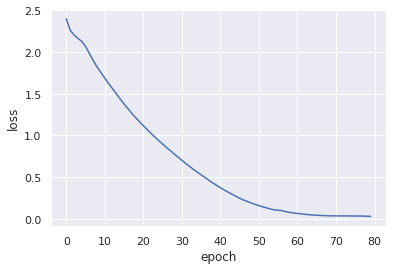

In [ ]:
plt.plot(np.arange(EPOCHS), train_loss_results_igbo )
plt.ylabel('loss')
plt.xlabel('epoch')

Text(0.5, 0, 'epoch')

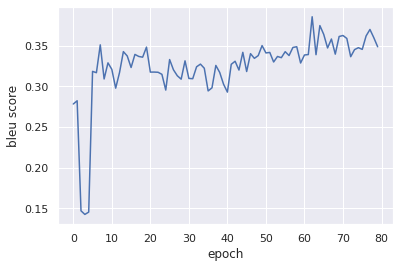

In [ ]:
#bleu score per epoch
plt.plot(np.arange(EPOCHS), bleu_score )
plt.ylabel('bleu score')
plt.xlabel('epoch')

## Summary
  It took around 100 mins to train the model on around 52k sentences and the BLEU score so far is 0.53 which is pretty good. Let's test the model on some random datapoints from the test data and check the attention scores.

# Conclusion and Future Works
1. The model seems to perform pretty good on short sentences but seems lost while translating long sentences, probably because of the small dataset.
2. In the future version I'll improve the performance of this model by adding more data and by some fine-tuning. I'll also use the other scoring functions and see which one works the best.
3.Thanks for reading, hope the notebook was useful! Comments and feedbacks are most welcomed!
4. Stay strong! Keep on learning!
